# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---


## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [132]:
# tu código aquí
import pandas as pd

# tu código aquí
# Cargar el dataset
df = pd.read_csv('../assignment-5-grupo-1/dataset/UJIIndoorLoc/trainingData.csv')

# Mostrar las primeras filas
display(df.head())


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [133]:
# tu código aquí# tu código aquí
# Separar características y variable objetivo
X = df.loc[:, df.columns.str.startswith('WAP')]
y = df['FLOOR']

# Verificar valores atípicos en las señales WiFi
display(X)
#display(y)


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520
0,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
1,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
2,100,100,100,100,100,100,100,-97,100,100,...,100,100,100,100,100,100,100,100,100,100
3,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
4,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19932,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
19933,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
19934,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
19935,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100


--- 

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [134]:
# tu código aquí
# Reemplazar todos los valores 100 por -100 en las señales WiFi
X = X.replace(100, -100)
display(X.head())

,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP511,WAP512,WAP513,WAP514,WAP515,WAP516,WAP517,WAP518,WAP519,WAP520
0,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
1,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
2,-100,-100,-100,-100,-100,-100,-100,-97,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
3,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
4,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [135]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def preparar_datos_csv(ruta_csv, columna_objetivo='FLOOR', random_state=42):
    # Cargar el dataset
    df = pd.read_csv(ruta_csv)
    # Seleccionar columnas WAP y la columna objetivo
    X = df.loc[:, df.columns.str.startswith('WAP')]
    y = df[columna_objetivo]
    # Reemplazar valores 100 por -100 en señales WiFi
    X = X.replace(100, -100)
    # División estratificada en train (80%) y val (20%)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )
    

    # Normalización MinMax (ajustar solo con train)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.fit_transform(X_val)
    
    # Retornar conjuntos normalizados y etiquetas
    return X_train_scaled, X_val_scaled, y_train.values, y_val.values
# Ejemplo de uso:
X_train, X_val, y_train, y_val = preparar_datos_csv('../assignment-5-grupo-1/dataset/UJIIndoorLoc/trainingData.csv')
print(X_train)


def preparar_datos_csv(ruta_csv, columna_objetivo='FLOOR', random_state=42):
    # Cargar el dataset
    df = pd.read_csv(ruta_csv)
    # Seleccionar columnas WAP y la columna objetivo
    X = df.loc[:, df.columns.str.startswith('WAP')]
    y_test = df[columna_objetivo]
    # Reemplazar valores 100 por -100 en señales WiFi
    X = X.replace(100, -100)
    
    # Normalización MinMax (ajustar solo con train)
    scaler = MinMaxScaler()
    X_test = scaler.fit_transform(X)
    # Retornar conjuntos normalizados y etiquetas
    return X_test, y_test,
# Ejemplo de uso:
X_test, y_test = preparar_datos_csv('../assignment-5-grupo-1/dataset/UJIIndoorLoc/validationData.csv')
print(X_test)
print("X_train - valor mínimo:", X_train.min(), "valor máximo:", X_train.max())
print("X_val   - valor mínimo:", X_val.min(), "valor máximo:", X_val.max())
print("X_test - valor mínimo:", X_test.min(), "valor máximo:", X_test.max())


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
X_train - valor mínimo: 0.0 valor máximo: 1.0000000000000004
X_val   - valor mínimo: 0.0 valor máximo: 1.0000000000000004
X_test - valor mínimo: 0.0 valor máximo: 1.0000000000000004


---
## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size: 32**
- **Sin Dropout ni BatchNormalization**


### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```text
   Input (520)
   → Linear(128) + ReLU
   → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64) + ReLU
   → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```text
   Input (520)
   → Linear(512) + ReLU
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64)  + ReLU
   → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```text
   Input (520)
   → Linear(1024) + ReLU
   → Linear(512)  + ReLU
   → Linear(256)  + ReLU
   → Linear(128)  + ReLU
   → Linear(64)   + ReLU
   → Linear(4)
   ```


### Instrucciones

- Implementa cada arquitectura como una subclase de `nn.Module` en PyTorch.
- Entrena durante **20 épocas**, utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y validación (`X_val`, `y_val`).
- Registra la **pérdida de entrenamiento y validación** por época en un gráfico.
- Grafica la evolución de la pérdida para analizar tendencias de aprendizaje, sobreajuste o subajuste.
- Evalúa el modelo final con el conjunto de test (`X_test`, `y_test`) y reporta:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**

In [136]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

# ─── Global Config ─────────────────────────────────────────────
EPOCHS = 20
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

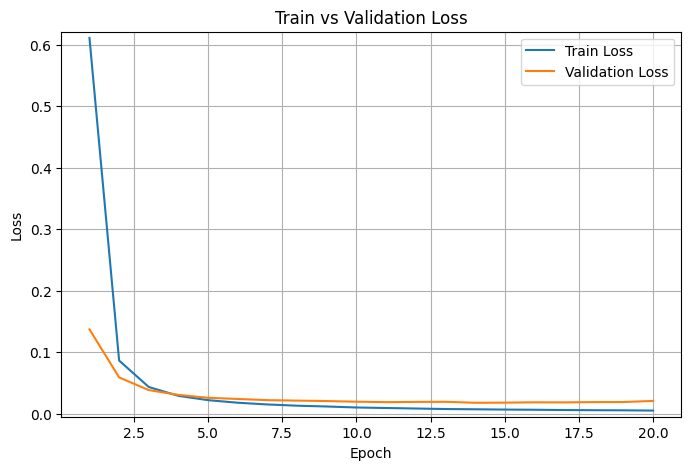

Epoch 20/20 | Train Loss: 0.0051 Acc: 0.9979 | Val Loss: 0.0208 Acc: 0.9940 | Time: 0.7s


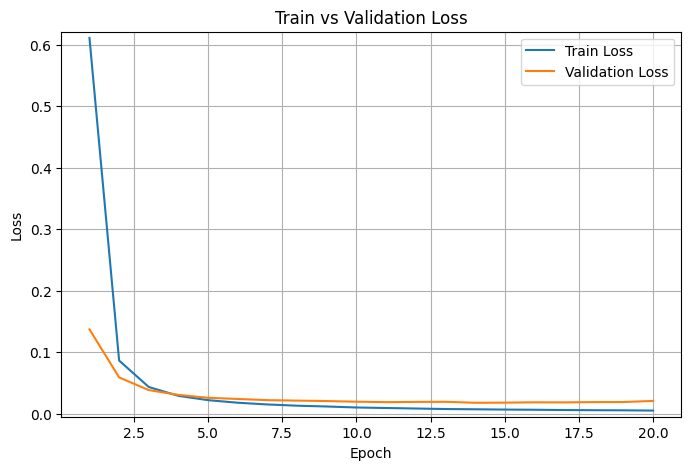

Tiempo total de entrenamiento: 15.42 segundos
Test Accuracy:  0.8983
Test Precision: 0.9022
Test Recall:    0.8983
Test F1-score:  0.8987


In [137]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import clear_output, display

# Aqruitectura 1
# ─── Define the neural network ─────────────────────────────────
class Aqru1(nn.Module):
    def __init__(self):
        super(Aqru1, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(520, 128),
            nn.ReLU(),
            nn.Linear(128, 5),
        )
        

    def forward(self, x):
        return self.net(x)

model = Aqru1().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total


# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    # Ajustar los límites del eje y automáticamente según los datos
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

plt.ioff()
plt.show()
total_train_time1 = time.time() - start_time
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_a1 = accuracy_score(all_labels, all_preds)
precision_a1 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_a1 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_a1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time1:.2f} segundos")
print(f"Test Accuracy:  {accuracy_a1:.4f}")
print(f"Test Precision: {precision_a1:.4f}")
print(f"Test Recall:    {recall_a1:.4f}")
print(f"Test F1-score:  {f1_a1:.4f}")

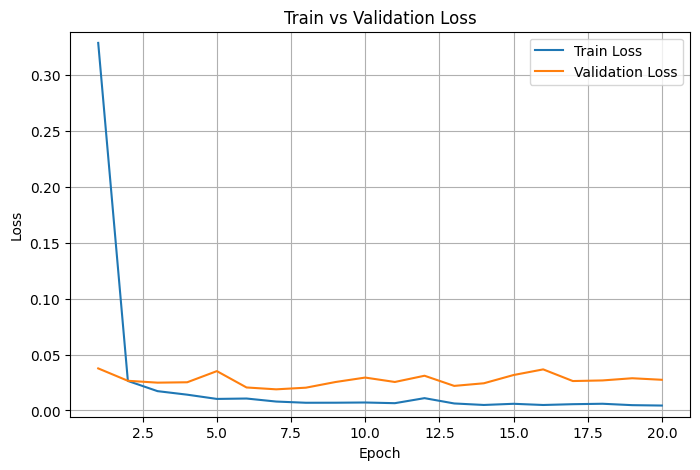

Epoch 20/20 | Train Loss: 0.0044 Acc: 0.9979 | Val Loss: 0.0274 Acc: 0.9932 | Time: 0.8s


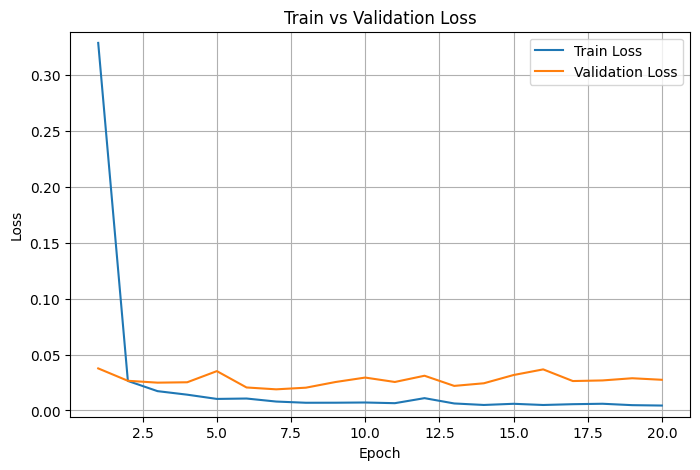

Tiempo total de entrenamiento: 16.31 segundos
Test Accuracy:  0.9118
Test Precision: 0.9140
Test Recall:    0.9118
Test F1-score:  0.9121


In [138]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import clear_output, display

# Aqruitectura 2
# ─── Define the neural network ─────────────────────────────────
class Aqrui2(nn.Module):
    def __init__(self):
        super(Aqrui2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(520, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 5),
        )
        

    def forward(self, x):
        return self.net(x)

model = Aqrui2().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total


# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

plt.ioff()
plt.show()

total_train_time2 = time.time() - start_time
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_a2 = accuracy_score(all_labels, all_preds)
precision_a2 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_a2 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_a2 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time2:.2f} segundos")
print(f"Test Accuracy:  {accuracy_a2:.4f}")
print(f"Test Precision: {precision_a2:.4f}")
print(f"Test Recall:    {recall_a2:.4f}")
print(f"Test F1-score:  {f1_a2:.4f}")

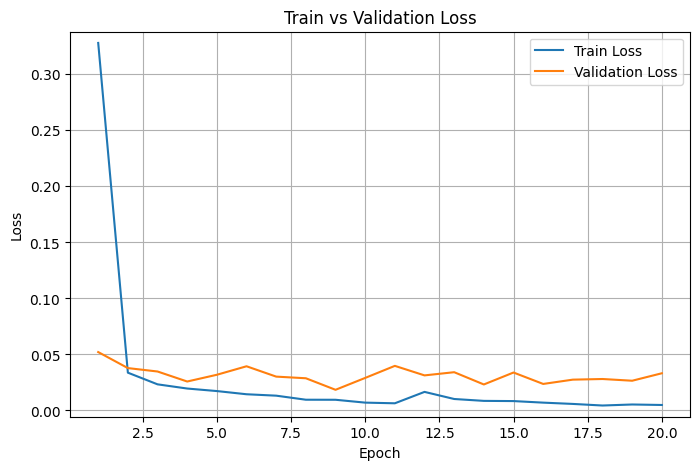

Epoch 20/20 | Train Loss: 0.0049 Acc: 0.9979 | Val Loss: 0.0332 Acc: 0.9900 | Time: 0.9s


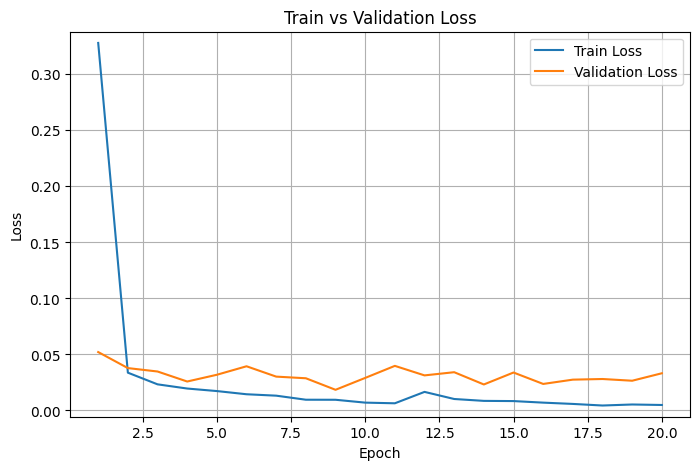

Tiempo total de entrenamiento: 17.20 segundos
Test Accuracy:  0.9199
Test Precision: 0.9207
Test Recall:    0.9199
Test F1-score:  0.9201


In [139]:
# Aqruitectura 3
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import clear_output, display

# Aqruitectura 3
# ─── Define the neural network ─────────────────────────────────
class Aqrui3(nn.Module):
    def __init__(self):
        super(Aqrui3, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(520, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5),
        )
        

    def forward(self, x):
        return self.net(x)

model = Aqrui3().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total


# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

plt.ioff()
plt.show()

total_train_time3 = time.time() - start_time
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_a3 = accuracy_score(all_labels, all_preds)
precision_a3 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_a3 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_a3 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time3:.2f} segundos")
print(f"Test Accuracy:  {accuracy_a3:.4f}")
print(f"Test Precision: {precision_a3:.4f}")
print(f"Test Recall:    {recall_a3:.4f}")
print(f"Test F1-score:  {f1_a3:.4f}")

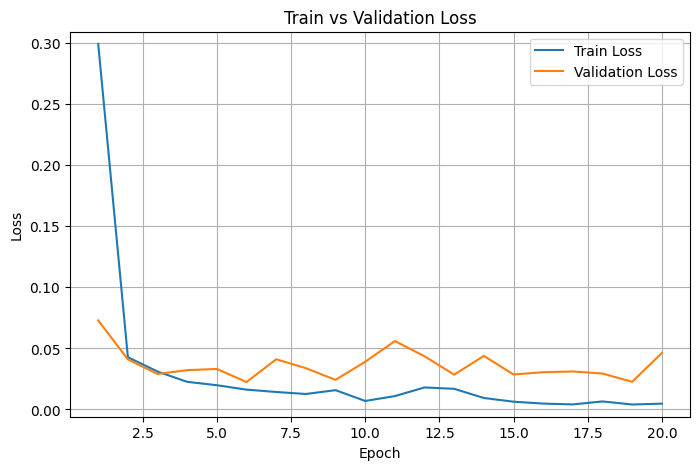

Epoch 20/20 | Train Loss: 0.0048 Acc: 0.9976 | Val Loss: 0.0462 Acc: 0.9905 | Time: 0.9s


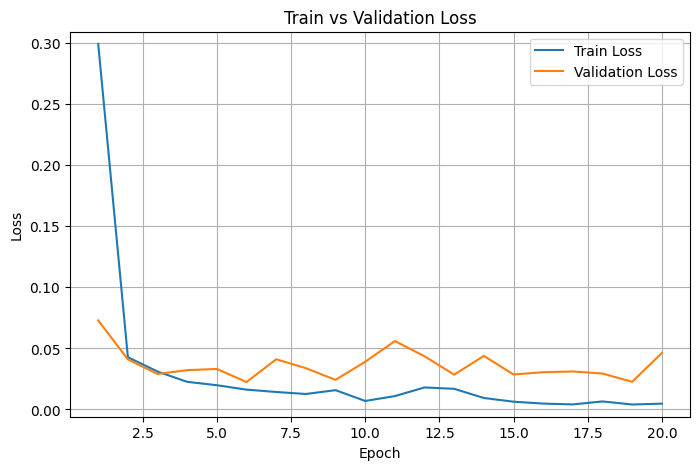

Tiempo total de entrenamiento: 17.79 segundos
Test Accuracy:  0.9181
Test Precision: 0.9190
Test Recall:    0.9181
Test F1-score:  0.9182


In [140]:
# Aqruitectura 4
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import clear_output, display

# Aqruitectura 4
# ─── Define the neural network ─────────────────────────────────
class Aqrui4(nn.Module):
    def __init__(self):
        super(Aqrui4, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(520, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5),
        )
        

    def forward(self, x):
        return self.net(x)

model = Aqrui4().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total


# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

plt.ioff()
plt.show()
    
total_train_time4 = time.time() - start_time
# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_a4 = accuracy_score(all_labels, all_preds)
precision_a4 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_a4 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_a4 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time4:.2f} segundos")
print(f"Test Accuracy:  {accuracy_a4:.4f}")
print(f"Test Precision: {precision_a4:.4f}")
print(f"Test Recall:    {recall_a4:.4f}")
print(f"Test F1-score:  {f1_a4:.4f}")

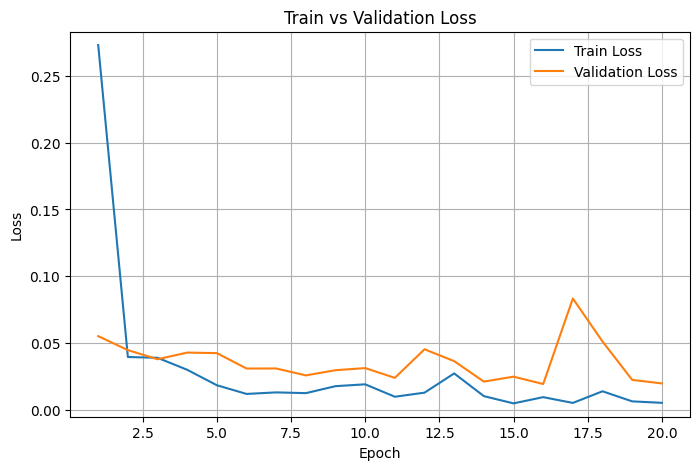

Epoch 20/20 | Train Loss: 0.0052 Acc: 0.9977 | Val Loss: 0.0197 Acc: 0.9945 | Time: 1.0s


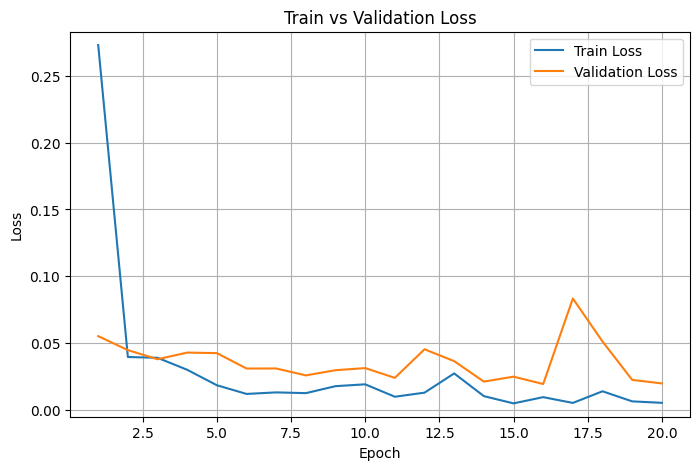

Tiempo total de entrenamiento: 19.36 segundos
Test Accuracy:  0.9145
Test Precision: 0.9167
Test Recall:    0.9145
Test F1-score:  0.9147


In [141]:
import time

# Aqruitectura 5
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import clear_output, display

# Aqruitectura 5
# ─── Define the neural network ─────────────────────────────────
class Aqrui5(nn.Module):
    def __init__(self):
        super(Aqrui5, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(520, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5),
        )
        

    def forward(self, x):
        return self.net(x)

model = Aqrui5().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total


# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

# Medir tiempo de entrenamiento
start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

# Tiempo total de entrenamiento
total_train_time5 = time.time() - start_time

plt.ioff()
plt.show()
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_a5 = accuracy_score(all_labels, all_preds)
precision_a5 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_a5 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_a5 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time5:.2f} segundos")
print(f"Test Accuracy:  {accuracy_a5:.4f}")
print(f"Test Precision: {precision_a5:.4f}")
print(f"Test Recall:    {recall_a5:.4f}")
print(f"Test F1-score:  {f1_a5:.4f}")

---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).

### Formato de la tabla:

| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 2         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 3         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 4         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 5         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |


**Nota:** Puedes medir el tiempo con `time.time()` al inicio y final del entrenamiento de cada modelo.

---


In [142]:
from IPython.display import Markdown, display

tabla = f"""
| Arquitectura   | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|----------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1 | {accuracy_a1:.4f}    | {precision_a1:.4f}     | {recall_a1:.4f}  | {f1_a1:.4f}    | {total_train_time1:.1f}                         |
| Arquitectura 2 | {accuracy_a2:.4f}    | {precision_a2:.4f}     | {recall_a2:.4f}  | {f1_a2:.4f}    | {total_train_time2:.1f}                         |
| Arquitectura 3 | {accuracy_a3:.4f}    | {precision_a3:.4f}     | {recall_a3:.4f}  | {f1_a3:.4f}    | {total_train_time3:.1f}                         |
| Arquitectura 4 | {accuracy_a4:.4f}    | {precision_a4:.4f}     | {recall_a4:.4f}  | {f1_a4:.4f}    | {total_train_time4:.1f}                         |
| Arquitectura 5 | {accuracy_a5:.4f}    | {precision_a5:.4f}     | {recall_a5:.4f}  | {f1_a5:.4f}    | {total_train_time5:.1f}                         |
"""

display(Markdown(tabla))


| Arquitectura   | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|----------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1 | 0.8983    | 0.9022     | 0.8983  | 0.8987    | 15.4                         |
| Arquitectura 2 | 0.9118    | 0.9140     | 0.9118  | 0.9121    | 16.3                         |
| Arquitectura 3 | 0.9199    | 0.9207     | 0.9199  | 0.9201    | 17.2                         |
| Arquitectura 4 | 0.9181    | 0.9190     | 0.9181  | 0.9182    | 17.8                         |
| Arquitectura 5 | 0.9145    | 0.9167     | 0.9145  | 0.9147    | 19.4                         |


---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas:
     - Accuracy
     - Precision
     - Recall
     - F1-score

4. Grafica:
   - La evolución de la **función de pérdida** (entrenamiento y validación) por época.
---


In [143]:
# Aqruitectura 2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import clear_output, display
# ─── Define the neural network ─────────────────────────────────
class Aqrui4(nn.Module):
    def __init__(self):
        super(Aqrui4, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(520, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5),
        )
        

    def forward(self, x):
        return self.net(x)



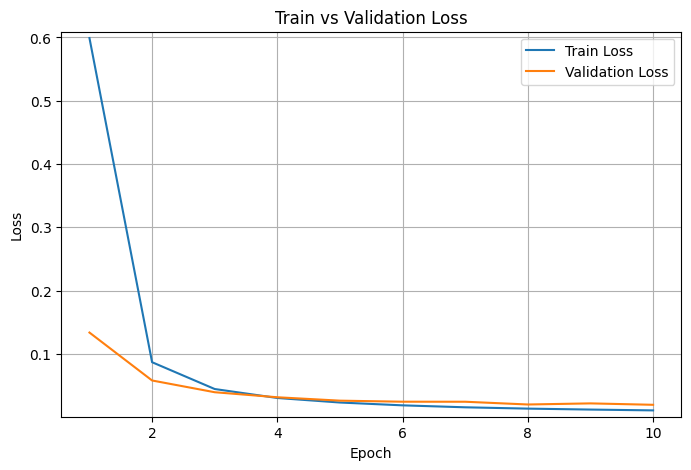

Epoch 10/10 | Train Loss: 0.0107 Acc: 0.9963 | Val Loss: 0.0195 Acc: 0.9937 | Time: 0.8s


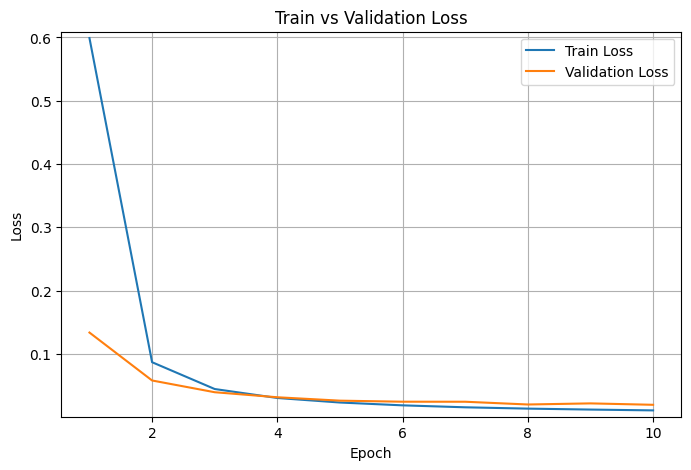

Tiempo total de entrenamiento: 7.83 segundos
Test Accuracy:  0.9046
Test Precision: 0.9094
Test Recall:    0.9046
Test F1-score:  0.9053


In [144]:

EPOCHS = 10


model = Aqru1().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

# Medir tiempo de entrenamiento
start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    # Ajustar los límites del eje y automáticamente según los datos
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

# Tiempo total de entrenamiento
total_train_time_P10 = time.time() - start_time

plt.ioff()
plt.show()
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_P10 = accuracy_score(all_labels, all_preds)
precision_P10 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_P10 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_P10 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time_P10:.2f} segundos")
print(f"Test Accuracy:  {accuracy_P10:.4f}")
print(f"Test Precision: {precision_P10:.4f}")
print(f"Test Recall:    {recall_P10:.4f}")
print(f"Test F1-score:  {f1_P10:.4f}")

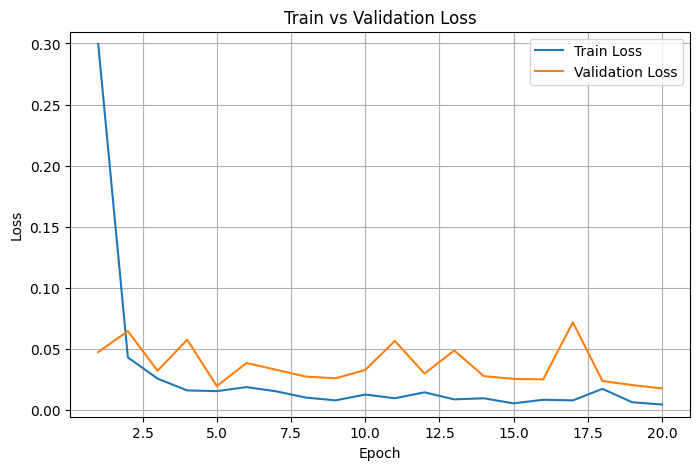

Epoch 20/20 | Train Loss: 0.0047 Acc: 0.9976 | Val Loss: 0.0179 Acc: 0.9952 | Time: 1.0s


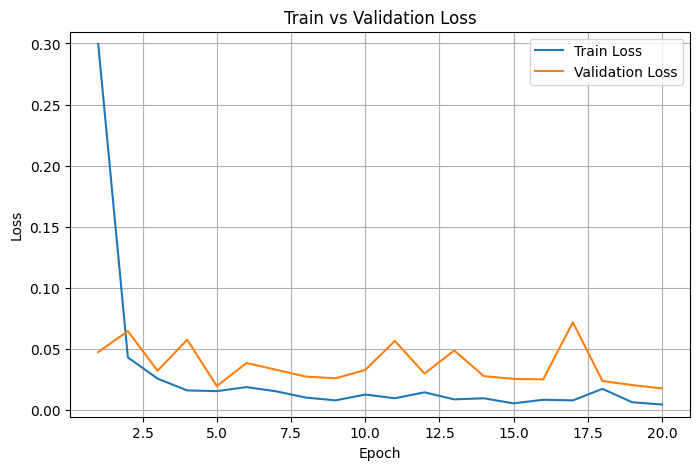

Tiempo total de entrenamiento: 19.40 segundos
Test Accuracy:  0.9244
Test Precision: 0.9273
Test Recall:    0.9244
Test F1-score:  0.9247


In [145]:
# tu código aquí  (evaluacion #2)

EPOCHS = 20


model = Aqrui4().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

# Medir tiempo de entrenamiento
start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    # Ajustar los límites del eje y automáticamente según los datos
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

# Tiempo total de entrenamiento
total_train_time_P20 = time.time() - start_time

plt.ioff()
plt.show()
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_P20 = accuracy_score(all_labels, all_preds)
precision_P20 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_P20 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_P20 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time_P20:.2f} segundos")
print(f"Test Accuracy:  {accuracy_P20:.4f}")
print(f"Test Precision: {precision_P20:.4f}")
print(f"Test Recall:    {recall_P20:.4f}")
print(f"Test F1-score:  {f1_P20:.4f}")

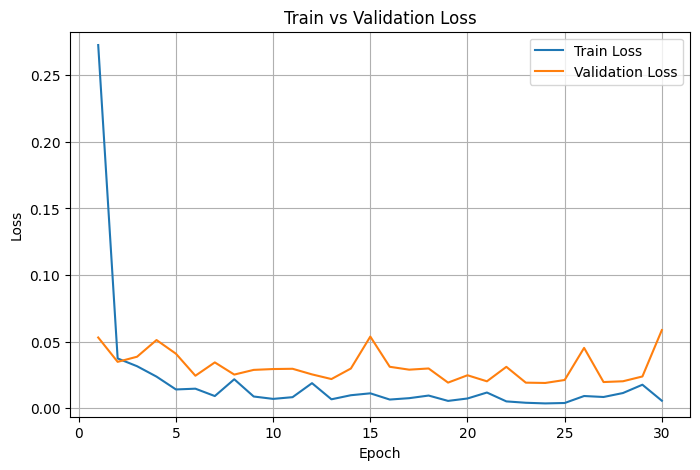

Epoch 30/30 | Train Loss: 0.0055 Acc: 0.9976 | Val Loss: 0.0586 Acc: 0.9900 | Time: 0.9s


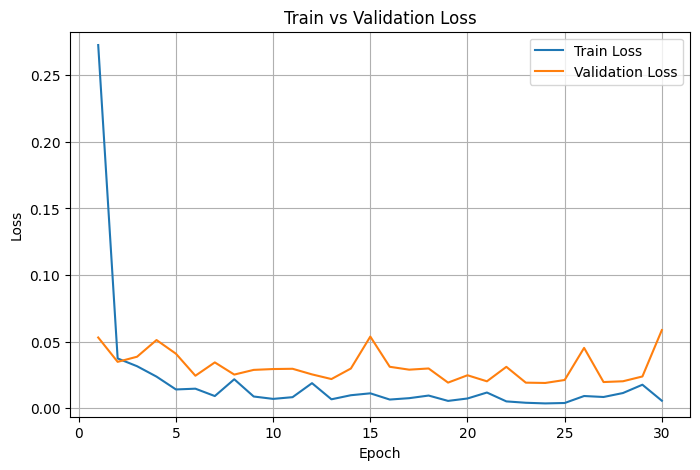

Tiempo total de entrenamiento: 28.17 segundos
Test Accuracy:  0.9244
Test Precision: 0.9251
Test Recall:    0.9244
Test F1-score:  0.9245


In [146]:
# tu código aquí (evaluacion #3)
# tu código aquí  (evaluacion #2)

EPOCHS = 30


model = Aqrui4().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

# Medir tiempo de entrenamiento
start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real (pérdidas)
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    # Ajustar los límites del eje y automáticamente según los datos
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

# Tiempo total de entrenamiento
total_train_time_P30 = time.time() - start_time

plt.ioff()
plt.show()
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_P30 = accuracy_score(all_labels, all_preds)
precision_P30 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_P30 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_P30 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time_P30:.2f} segundos")
print(f"Test Accuracy:  {accuracy_P30:.4f}")
print(f"Test Precision: {precision_P30:.4f}")
print(f"Test Recall:    {recall_P30:.4f}")
print(f"Test F1-score:  {f1_P30:.4f}")

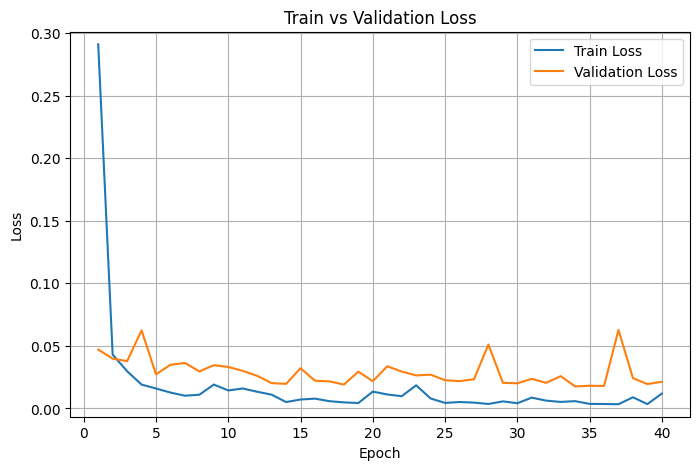

Epoch 40/40 | Train Loss: 0.0119 Acc: 0.9969 | Val Loss: 0.0213 Acc: 0.9947 | Time: 0.9s


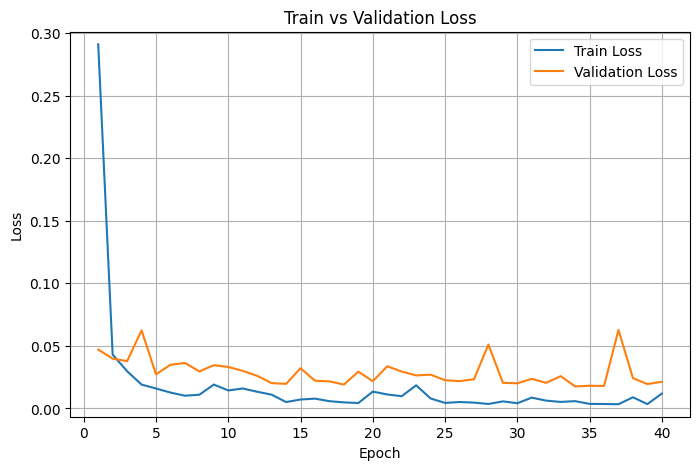

Tiempo total de entrenamiento: 36.87 segundos
Test Accuracy:  0.9145
Test Precision: 0.9180
Test Recall:    0.9145
Test F1-score:  0.9148


In [147]:
# tu código aquí (evaluacion #4)

EPOCHS = 40


model = Aqrui4().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

# Medir tiempo de entrenamiento
start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    # Ajustar los límites del eje y automáticamente según los datos
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

# Tiempo total de entrenamiento
total_train_time_P40 = time.time() - start_time

plt.ioff()
plt.show()
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_P40 = accuracy_score(all_labels, all_preds)
precision_P40 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_P40 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_P40 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time_P40:.2f} segundos")
print(f"Test Accuracy:  {accuracy_P40:.4f}")
print(f"Test Precision: {precision_P40:.4f}")
print(f"Test Recall:    {recall_P40:.4f}")
print(f"Test F1-score:  {f1_P40:.4f}")

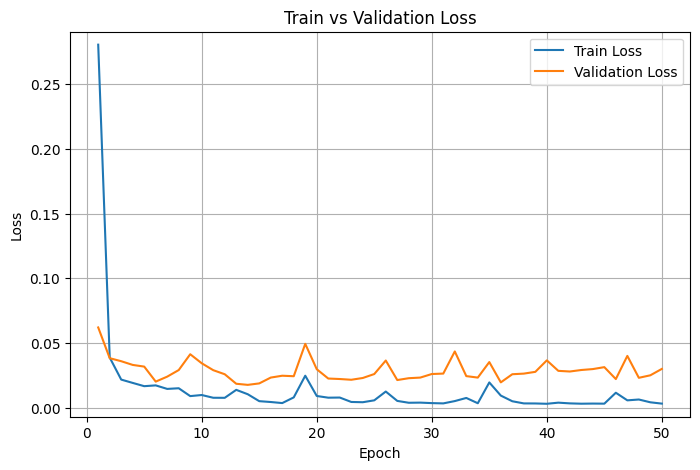

Epoch 50/50 | Train Loss: 0.0032 Acc: 0.9979 | Val Loss: 0.0300 Acc: 0.9952 | Time: 1.0s


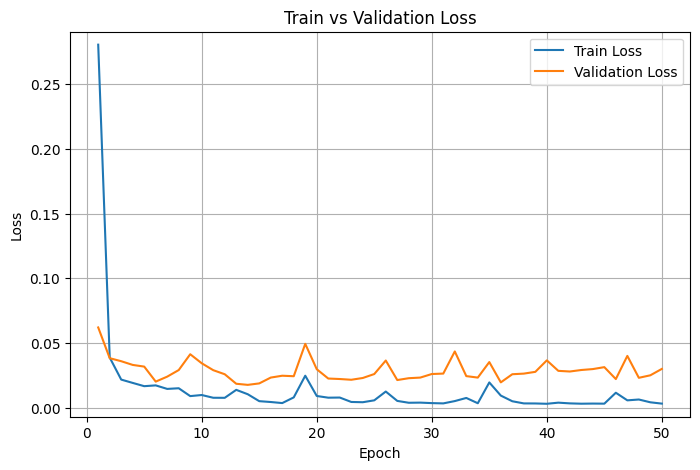

Tiempo total de entrenamiento: 50.59 segundos
Test Accuracy:  0.9109
Test Precision: 0.9133
Test Recall:    0.9109
Test F1-score:  0.9112


In [148]:
# tu código aquí (evaluacion #5)

EPOCHS = 50


model = Aqrui4().to(DEVICE)
criterion = nn.CrossEntropyLoss()

# L2 Regularization (weight decay)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ─── Train and Evaluate ────────────────────────────────────────
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total

def evaluate_loss(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return total_loss / total, correct / total

# ─── Training Loop con Gráficas en Tiempo Real ─────────────────────────────

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

plt.ion()
fig, ax = plt.subplots(figsize=(8, 5))

# Medir tiempo de entrenamiento
start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate_loss(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Actualizar gráfica en tiempo real
    clear_output(wait=True)
    ax.clear()
    ax.plot(range(1, epoch + 2), train_losses, label='Train Loss')
    ax.plot(range(1, epoch + 2), val_losses, label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Train vs Validation Loss')
    # Ajustar los límites del eje y automáticamente según los datos
    ax.set_ylim(
        min(min(train_losses), min(val_losses)) - 0.01,
        max(max(train_losses), max(val_losses)) + 0.01
    )
    ax.legend()
    ax.grid(True)
    display(fig)
    

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {time.time() - t0:.1f}s")

# Tiempo total de entrenamiento
total_train_time_P50 = time.time() - start_time

plt.ioff()
plt.show()
    

# ─── Final Evaluation ──────────────────────────────────────────
# Evaluación final en test_loader
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

accuracy_P50 = accuracy_score(all_labels, all_preds)
precision_P50 = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_P50 = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_P50 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Tiempo total de entrenamiento: {total_train_time_P50:.2f} segundos")
print(f"Test Accuracy:  {accuracy_P50:.4f}")
print(f"Test Precision: {precision_P50:.4f}")
print(f"Test Recall:    {recall_P50:.4f}")
print(f"Test F1-score:  {f1_P50:.4f}")


---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

- Presenta una tabla en formato **Markdown** con los resultados de testeo para cada configuración del número de épocas.
- La tabla debe incluir las siguientes columnas:
  - Número de épocas
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Tiempo de entrenamiento (en segundos)

### Formato de la tabla:

| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 20     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 30     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 40     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 50     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |

> Reemplaza los valores con los resultados reales obtenidos. Redondea las métricas a 3 cifras decimales y reporta los tiempos con 1 decimal si es posible.


In [149]:
from IPython.display import Markdown, display

# Tu tabla de resultados aquí0
tabla_epocas = f"""
| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | {accuracy_P10:.3f}    | {precision_P10:.3f}     | {recall_P10:.3f}  | {f1_P10:.3f}    | {total_train_time_P10:.1f}                         |
| 20     | {accuracy_P20:.3f}    | {precision_P20:.3f}     | {recall_P20:.3f}  | {f1_P20:.3f}    | {total_train_time_P20:.1f}                         |
| 30     | {accuracy_P30:.3f}    | {precision_P30:.3f}     | {recall_P30:.3f}  | {f1_P30:.3f}    | {total_train_time_P30:.1f}                         |
| 40     | {accuracy_P40:.3f}    | {precision_P40:.3f}     | {recall_P40:.3f}  | {f1_P40:.3f}    | {total_train_time_P40:.1f}                         |
| 50     | {accuracy_P50:.3f}    | {precision_P50:.3f}     | {recall_P50:.3f}  | {f1_P50:.3f}    | {total_train_time_P50:.1f}                         |
"""

display(Markdown(tabla_epocas))


| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.905    | 0.909     | 0.905  | 0.905    | 7.8                         |
| 20     | 0.924    | 0.927     | 0.924  | 0.925    | 19.4                         |
| 30     | 0.924    | 0.925     | 0.924  | 0.924    | 28.2                         |
| 40     | 0.914    | 0.918     | 0.914  | 0.915    | 36.9                         |
| 50     | 0.911    | 0.913     | 0.911  | 0.911    | 50.6                         |


---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

1. **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**
2. **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**
3. **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**
4. **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**
5. **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**
6. **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**
7. **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**
8. **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**


**1. ¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**

La mejor arquitectura varía ligeramente cada vez que se ejecuta el script completo, debido a la aleatoriedad inherente en el entrenamiento y la inicialización de los pesos. En la mayoría de las ejecuciones, la arquitectura 3 y la arquitectura 4 alternan como ganadoras, obteniendo el mayor F1-score en el conjunto de testeo. Ambas ofrecen un buen equilibrio entre profundidad y capacidad de generalización, mostrando un rendimiento superior y estable frente a las demás configuraciones. Esto sugiere que, para este problema, una red con dos o tres capas ocultas y una cantidad intermedia de neuronas logra capturar mejor la complejidad de los datos sin caer en sobreajuste.

**2. ¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**

La arquitectura con peor desempeño fue la Arquitectura 1, que obtuvo el menor F1-score y accuracy en el conjunto de testeo. Esto probablemente se debió a su baja capacidad de representación: solo cuenta con una capa oculta y pocas neuronas, lo que limita su habilidad para capturar patrones complejos en los datos. Al ser demasiado simple, la red no logra modelar adecuadamente la variabilidad de las señales WiFi y las relaciones no lineales necesarias para una clasificación precisa del piso.

**3. ¿Cómo influye el número de capas ocultas en el comportamiento de la red?**

El número de capas ocultas afecta directamente la capacidad de la red para aprender representaciones complejas de los datos. Con pocas capas, la red puede ser demasiado simple y no capturar patrones relevantes, lo que lleva a un bajo desempeño (subajuste). Al aumentar el número de capas ocultas, la red puede modelar relaciones más sofisticadas y mejorar la precisión, como se observa en las arquitecturas intermedias (2-4 capas). Sin embargo, agregar demasiadas capas puede incrementar el riesgo de sobreajuste y aumentar el tiempo de entrenamiento sin mejoras significativas en las métricas. Por lo tanto, existe un punto óptimo donde la red es suficientemente profunda para aprender bien, pero no tan compleja como para perder capacidad de generalización.

**4. ¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**

La mejor cantidad de épocas fue **20**, ya que en ese punto el modelo alcanzó su máximo F1-score y accuracy en el conjunto de testeo (F1-score ≈ 0.925, accuracy ≈ 0.924). Entrenar por más épocas no mejoró las métricas y, de hecho, se observó una ligera disminución en el rendimiento, lo que indica inicio de sobreajuste. Además, el tiempo de entrenamiento aumentó considerablemente sin aportar beneficios adicionales. Por lo tanto, 20 épocas representa el mejor equilibrio entre desempeño y eficiencia computacional.

**5. ¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**

Sí, se detectaron signos de sobreajuste en los modelos más profundos y al aumentar el número de épocas. El sobreajuste se identificó porque la pérdida de entrenamiento seguía disminuyendo y la precisión en el conjunto de entrenamiento era muy alta, mientras que la pérdida y las métricas en el conjunto de validación y testeo dejaban de mejorar o incluso empeoraban. Esto indica que el modelo estaba memorizando los datos de entrenamiento en lugar de generalizar. Por otro lado, el subajuste se observó en la arquitectura más simple (Arquitectura 1), donde tanto las métricas de entrenamiento como de validación eran bajas, mostrando que el modelo no tenía suficiente capacidad para aprender los patrones del dataset.

**6. ¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**

Se observó que al aumentar el número de épocas más allá de 20, el tiempo de entrenamiento creció considerablemente, pero las métricas de testeo (accuracy, precision, recall y F1-score) dejaron de mejorar e incluso disminuyeron ligeramente. Por ejemplo, entrenar durante 40 o 50 épocas requirió más del doble de tiempo que 20 épocas, pero el F1-score y la accuracy fueron menores. Esto indica que el mayor tiempo invertido no se tradujo en una mejor generalización, y que entrenar por más tiempo puede llevar al sobreajuste y a una eficiencia computacional innecesaria. Por lo tanto, el incremento en tiempo no justificó una mejora en el desempeño del modelo.

**7. ¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**

No, la arquitectura más profunda (Arquitectura 5) no fue la más precisa. Aunque tenía más capas y neuronas, su desempeño en accuracy y F1-score fue inferior al de las arquitecturas intermedias (3 y 4 capas ocultas). Esto demuestra que aumentar la profundidad no garantiza mejores resultados; puede llevar a sobreajuste, mayor tiempo de entrenamiento y menor capacidad de generalización. La mejor precisión se logró con arquitecturas balanceadas, lo que indica que para este problema una red demasiado compleja no aporta beneficios y puede incluso perjudicar el rendimiento.

**8. ¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**

En el contexto de clasificación de piso en localización indoor, la **F1-score** es la métrica más importante. Esto se debe a que el problema es multiclase y puede existir desbalance entre las clases (algunos pisos pueden tener más muestras que otros). El F1-score combina precisión y recall en una sola métrica, proporcionando una visión equilibrada del desempeño del modelo, especialmente cuando los errores de clasificación pueden tener impacto en la experiencia del usuario o en aplicaciones críticas (por ejemplo, navegación o emergencias). Mientras que la accuracy puede verse inflada por clases mayoritarias, el F1-score refleja mejor la capacidad del modelo para identificar correctamente todas las clases, minimizando tanto falsos positivos como falsos negativos.

---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)      | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---

